In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import KernelPCA
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import warnings

warnings.filterwarnings('ignore')

In [2]:
newsgroups_train = fetch_20newsgroups(subset='train', 
                                      remove=('headers', 'footers', 'quotes'))

# prawdziwne etykiety
target = newsgroups_train.target
target_names = newsgroups_train.target_names

In [3]:
print(f"Wszystkie nazwy ({len(target_names)}) : {target_names}")

Wszystkie nazwy (20) : ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [4]:
pipeline = Pipeline([ # najpierw robi tego tfidf a następnie pca
    ('tfidf', TfidfVectorizer(stop_words='english', 
                             max_df=0.5,    # Ignoruj słowa, które są w > 50% dokumentów (zbyt częste)
                             min_df=5
                             )),      # Ignoruj słowa, które są w < 5 dokumentach (zbyt rzadkie/literówki)
    ('pca', KernelPCA(n_components=100, random_state=2137))
])

In [5]:
pca_matrix = pipeline.fit_transform(newsgroups_train.data)

In [6]:
print("Shape of PCA matrix:", pca_matrix.shape)

Shape of PCA matrix: (11314, 100)


średni dystanst do punktow z mojego klastra

$$ a(x_i) = \frac{1}{|C(x_i)|-1}\sum_{x_j\in C(x_i), x_i\neq x_j} d(x_i, x_j)$$

minimalny średni dystans do punktów z innego klastra

$$ b(x_i) = \min_{C \neq C(x_i)} \{ \frac{1}{|C|} \sum_{x_j\in C} d(x_i, x_j)\}$$

to maximum, jest dlatego, że moge mieć dalej do punktów z mojego klastra niż do innego, ale gdy tak nie jest to jest to po prostu jak zwięźle jest ten klaster upakowany, jeśli ta wartoćs jest bliska 1 to "mój klaster jest daleko od innego najbliższego do mnie"

$$ s(x_i) = \frac{b(x_i) - a(x_i)}{\max\{{a(x_i), b(x_i)}\}}$$


Silhouette, czyli najgorszy średni wynik tego współczynnika "dobrego upakowania" po wszystkich klastrach

$$ S = \max_{k=1\dots K}\{\frac{1}{|C_k|} \sum_{x\in C_k}s(x)\}$$

In [7]:
K_range = range(10, 21) # mamy 20 różnych nazw, więc na więcej klastórw (w taki sposób) nie ma co dzielić
silhouette_scores = []
inertia_values = [] 

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=2137, n_init=10)
    labels = kmeans.fit_predict(pca_matrix)
    
    score = silhouette_score(pca_matrix, labels)
    silhouette_scores.append(score)
    
    inertia_values.append(kmeans.inertia_) # to do tego łokcia
    print(f"Obliczono dla k={k}, Silhouette: {score:.4f}, Inercja: {kmeans.inertia_:.2f}")

Obliczono dla k=10, Silhouette: 0.0472, Inercja: 1104.66
Obliczono dla k=11, Silhouette: 0.0616, Inercja: 1097.96
Obliczono dla k=12, Silhouette: 0.0524, Inercja: 1080.63
Obliczono dla k=13, Silhouette: 0.0551, Inercja: 1070.63
Obliczono dla k=14, Silhouette: 0.0639, Inercja: 1059.91
Obliczono dla k=15, Silhouette: 0.0566, Inercja: 1048.59
Obliczono dla k=16, Silhouette: 0.0633, Inercja: 1038.05
Obliczono dla k=17, Silhouette: 0.0439, Inercja: 1027.85
Obliczono dla k=18, Silhouette: 0.0551, Inercja: 1024.51
Obliczono dla k=19, Silhouette: 0.0544, Inercja: 1013.52
Obliczono dla k=20, Silhouette: 0.0316, Inercja: 1006.54


In [8]:
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]
print(f"Optymalna liczba klastrów (wg Silhouette): {optimal_k_silhouette}")

Optymalna liczba klastrów (wg Silhouette): 14


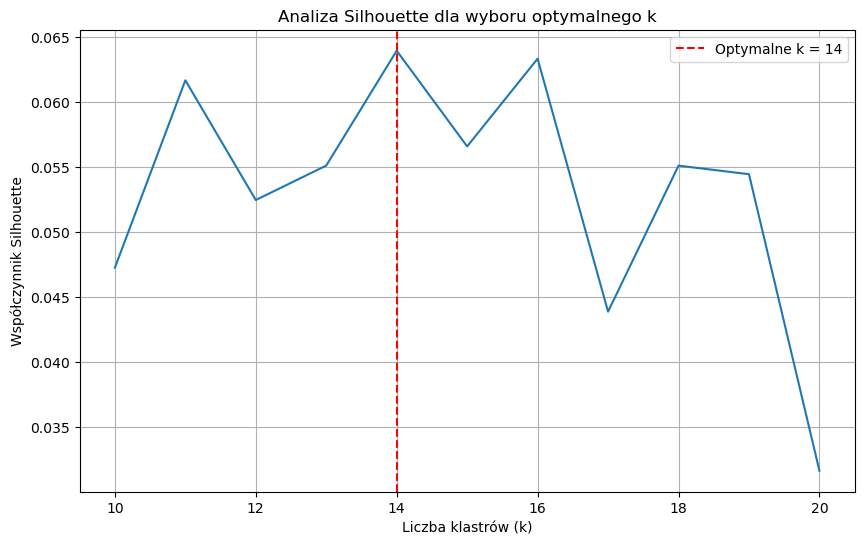

In [9]:


# Wykres Silhouette
plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, '-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Współczynnik Silhouette')
plt.title('Analiza Silhouette dla wyboru optymalnego k')
plt.axvline(x=optimal_k_silhouette, color='red', linestyle='--', 
            label=f'Optymalne k = {optimal_k_silhouette}')
plt.legend()
plt.grid(True)
plt.show()

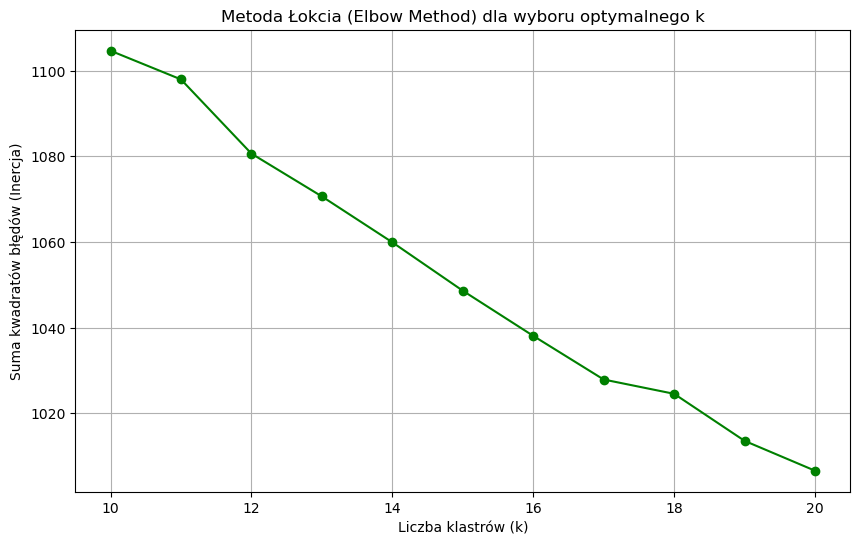

In [10]:
# Wykres Metody Łokcia
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia_values, 'go-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Suma kwadratów błędów (Inercja)')
plt.title('Metoda Łokcia (Elbow Method) dla wyboru optymalnego k')
plt.grid(True)
plt.show()

Łokciem były jakiś taki zauwazalny spadek w tempie spadku wartości, tutaj wygląda to na 17, bo w 18 jest mnieszy spadek niż wcześniej

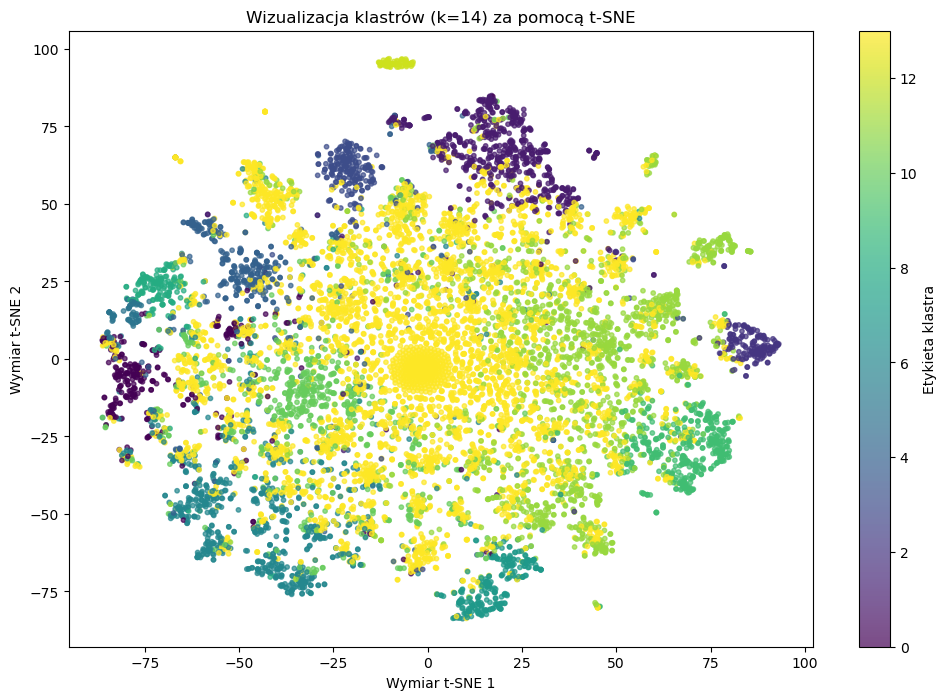

In [16]:
k = optimal_k_silhouette
# k = 17 # ~ łokieć
final_kmeans = KMeans(n_clusters=k, random_state=2137, n_init=10)
final_labels = final_kmeans.fit_predict(pca_matrix)

tsne = TSNE(n_components=2, random_state=2137, perplexity=15) 
matrix_2d = tsne.fit_transform(pca_matrix)

plt.figure(figsize=(12, 8))
plt.scatter(matrix_2d[:, 0], matrix_2d[:, 1], c=final_labels, cmap='viridis', alpha=0.7, s=10)
plt.title(f'Wizualizacja klastrów (k={k}) za pomocą t-SNE')
plt.xlabel('Wymiar t-SNE 1')
plt.ylabel('Wymiar t-SNE 2')
plt.colorbar(label='Etykieta klastra')
plt.show()

In [15]:
print(f"--- Analiza tematyczna dla k={k} ---")

for i in range(k):
    
    cluster_indices = np.where(final_labels == i)[0]
    
    if len(cluster_indices) == 0:
        print(f"\n--- Pusty Klaster {i} ---")
        continue

    # prawdziwe etykiety w klastrze

    true_labels_in_cluster = target[cluster_indices]
    
    # ile razy wystąpiła każda prawdziwa etykieta
    counts = np.bincount(true_labels_in_cluster, minlength=len(target_names)) #minlength A minimum number of bins for the output array.
    
    # 5 najczęstsze prawdziwe' etykiet
    top_labels_indices = counts.argsort()[-5:][::-1]
    
    print(f"\n--- Klaster {i} (Liczba dokumentów: {len(cluster_indices)}) ---")
    
    # 5 najczęstsze tematy
    for idx in top_labels_indices:
        if counts[idx] > 0:
            name = target_names[idx]
            count = counts[idx]
            percentage = 100 * count / len(cluster_indices)
            print(f"  - {name}: {count} dokumentów ({percentage:.1f}%)")

--- Analiza tematyczna dla k=14 ---

--- Klaster 0 (Liczba dokumentów: 294) ---
  - comp.sys.ibm.pc.hardware: 107 dokumentów (36.4%)
  - comp.os.ms-windows.misc: 56 dokumentów (19.0%)
  - comp.sys.mac.hardware: 52 dokumentów (17.7%)
  - comp.graphics: 40 dokumentów (13.6%)
  - misc.forsale: 26 dokumentów (8.8%)

--- Klaster 1 (Liczba dokumentów: 646) ---
  - rec.sport.hockey: 385 dokumentów (59.6%)
  - rec.sport.baseball: 247 dokumentów (38.2%)
  - misc.forsale: 8 dokumentów (1.2%)
  - sci.space: 2 dokumentów (0.3%)
  - rec.motorcycles: 2 dokumentów (0.3%)

--- Klaster 2 (Liczba dokumentów: 171) ---
  - talk.politics.mideast: 167 dokumentów (97.7%)
  - talk.religion.misc: 1 dokumentów (0.6%)
  - talk.politics.misc: 1 dokumentów (0.6%)
  - talk.politics.guns: 1 dokumentów (0.6%)
  - alt.atheism: 1 dokumentów (0.6%)

--- Klaster 3 (Liczba dokumentów: 261) ---
  - rec.autos: 198 dokumentów (75.9%)
  - rec.motorcycles: 29 dokumentów (11.1%)
  - misc.forsale: 12 dokumentów (4.6%)
  - sci.el

Wygląda to nawet okej, w prawie wszystkich z klastórw tematy wydają się (po ludzku) do siebie pasować